In [1]:
import sys

def get_variable_sizes(scope_vars):
    sizes = []
    for name, val in scope_vars.items():
        try:
            size = sys.getsizeof(val)
            sizes.append((name, size))
        except TypeError:
            pass
    sizes.sort(key=lambda x: x[1], reverse=True)
    for name, size in sizes:
        print(f"{name:<30} {size / 1024 ** 2:>10.2f} MB")

get_variable_sizes(locals())

_i1                                  0.00 MB
_oh                                  0.00 MB
Out                                  0.00 MB
__vsc_ipynb_file__                   0.00 MB
open                                 0.00 MB
get_variable_sizes                   0.00 MB
_ih                                  0.00 MB
In                                   0.00 MB
__doc__                              0.00 MB
__builtin__                          0.00 MB
__builtins__                         0.00 MB
sys                                  0.00 MB
_dh                                  0.00 MB
get_ipython                          0.00 MB
__name__                             0.00 MB
_                                    0.00 MB
__                                   0.00 MB
___                                  0.00 MB
_i                                   0.00 MB
_ii                                  0.00 MB
_iii                                 0.00 MB
exit                                 0.00 MB
quit      

# Setup & paths

In [2]:
# %% [markdown]
# # Training notebook (single-cohort)
# Cohort: set to "A", "B", or "C" to control filenames.

# %%
import os, json, random, datetime, math
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------- choose cohort label ----------
COHORT = "A"  # change to "B" or "C" in the other notebooks

# ---------- input data ----------
PKL_PATH = "A_data_10_sec_50.pkl"   # change per-cohort if needed

# ---------- output roots ----------
ROOT = Path("project")
DIR_MODELS   = ROOT / "models";    DIR_MODELS.mkdir(parents=True, exist_ok=True)
DIR_SPLITS   = ROOT / "splits";    DIR_SPLITS.mkdir(parents=True, exist_ok=True)
DIR_METRICS  = ROOT / "metrics";   DIR_METRICS.mkdir(parents=True, exist_ok=True)
DIR_PREDS    = ROOT / "preds";     DIR_PREDS.mkdir(parents=True, exist_ok=True)
DIR_FIGS     = ROOT / "figures";   DIR_FIGS.mkdir(parents=True, exist_ok=True)
DIR_LOGS     = ROOT / "logs";      DIR_LOGS.mkdir(parents=True, exist_ok=True)
DIR_STATS    = ROOT / "stats";     DIR_STATS.mkdir(parents=True, exist_ok=True)

# ---------- reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Load dataset & basic cleaning

In [3]:
# %% [markdown]
# ## 1) Load dataset

# %%
data = joblib.load(PKL_PATH)
x = data["x"]          # (N, 1280)
y = data["y"].astype(float)     # (N,)
c = data["c"].astype(int)       # (N,) caseid

print("Original:", x.shape)

# Remove any segment with NaNs in EEG
valid_mask = ~np.isnan(x).any(axis=1)
x = x[valid_mask]; y = y[valid_mask]; c = c[valid_mask]
print("Cleaned:", x.shape, "| NaNs in x:", np.isnan(x).sum())

# Optionally keep a vector of original global indices for preds
global_idx = np.arange(len(valid_mask))[valid_mask]


Original: (206301, 1280)
Cleaned: (205945, 1280) | NaNs in x: 0


# Subject-wise split (train/val/test) with simple stratification

In [4]:
# %% [markdown]
# ## 2) Subject-wise split
# Strategy: compute mean BIS per subject → stratify into low/mid/high → sample test subjects → sample val subjects from remaining → rest = train.

# %%
from collections import defaultdict

# indices per caseid
caseid_to_indices = defaultdict(list)
for idx, cid in enumerate(c):
    caseid_to_indices[cid].append(idx)

print("Unique subjects:", len(caseid_to_indices))

# per-subject mean BIS
case_stats = []
for cid, idxs in caseid_to_indices.items():
    bis_vals = y[idxs]
    case_stats.append({"caseid": cid,
                       "mean_bis": float(np.mean(bis_vals)),
                       "count": len(idxs)})
df_stats = pd.DataFrame(case_stats).sort_values("mean_bis").reset_index(drop=True)

# pools
low_pool  = df_stats[df_stats["mean_bis"] < 40]
mid_pool  = df_stats[(df_stats["mean_bis"] >= 40) & (df_stats["mean_bis"] <= 60)]
high_pool = df_stats[df_stats["mean_bis"] > 60]

def sample_subjects(df, n):
    n = min(n, len(df))
    return set(df.sample(n, random_state=SEED)["caseid"].tolist())

# simple rule of thumb: 20% test, 10% val (by subjects), with at least 2 high-BIS if possible
S = len(df_stats)
n_test = max(3, round(0.2 * S))
n_val  = max(2, round(0.1 * S))

# target composition for test (roughly balanced across pools)
t_low  = max(1, round(0.33 * n_test))
t_mid  = max(1, round(0.34 * n_test))
t_high = max(1, n_test - t_low - t_mid)

test_low  = sample_subjects(low_pool,  t_low)
test_mid  = sample_subjects(mid_pool,  t_mid)
test_high = sample_subjects(high_pool, t_high)

test_caseids = set().union(test_low, test_mid, test_high)
remaining = [cid for cid in df_stats["caseid"].tolist() if cid not in test_caseids]

# val from remaining (stratified-ish)
rem_df = df_stats[df_stats["caseid"].isin(remaining)]
v_low  = sample_subjects(rem_df[rem_df["mean_bis"] < 40],                 max(1, round(0.1 * n_val)))
v_mid  = sample_subjects(rem_df[(rem_df["mean_bis"] >= 40) & (rem_df["mean_bis"] <= 60)], max(1, round(0.6 * n_val)))
v_high = sample_subjects(rem_df[rem_df["mean_bis"] > 60],                 max(1, n_val - len(v_low) - len(v_mid)))
val_caseids = set().union(v_low, v_mid, v_high)

train_caseids = set(df_stats["caseid"].tolist()) - test_caseids - val_caseids

print(f"Subjects → train={len(train_caseids)}, val={len(val_caseids)}, test={len(test_caseids)}")

# save split manifest
split_manifest = {
    "cohort": COHORT,
    "seed": SEED,
    "train_caseids": sorted(map(int, list(train_caseids))),
    "val_caseids": sorted(map(int, list(val_caseids))),
    "test_caseids": sorted(map(int, list(test_caseids))),
    "notes": {
        "window_len": 10.0,
        "stride_sec": 2.0,
        "preproc": "0.5–50 Hz, zero-phase; per-window z-score",
        "label": "BIS at end of window (estimation)"
    }
}
with open(DIR_SPLITS / f"split_{COHORT}.json", "w") as f:
    json.dump(split_manifest, f, indent=2)
print("Saved split JSON →", DIR_SPLITS / f"split_{COHORT}.json")


del case_stats, df_stats
del low_pool, mid_pool, high_pool
del test_low, test_mid, test_high
del remaining, rem_df
del v_low, v_mid, v_high
del split_manifest




Unique subjects: 50
Subjects → train=40, val=4, test=6
Saved split JSON → project\splits\split_A.json


# Build datasets & loaders (no clamp in loss)

In [5]:
# %% [markdown]
# ## 3) Datasets & DataLoaders

# %%
# gather indices by split
train_indices = [i for cid in train_caseids for i in caseid_to_indices[cid]]
val_indices   = [i for cid in val_caseids   for i in caseid_to_indices[cid]]
test_indices  = [i for cid in test_caseids  for i in caseid_to_indices[cid]]

class EEGBISDataset(Dataset):
    def __init__(self, x, y, c, idxs, global_idx=None):
        self.x = torch.tensor(x[idxs], dtype=torch.float32)
        self.y = torch.tensor(y[idxs], dtype=torch.float32)
        self.c = c[idxs]
        self.idxs = np.array(idxs)
        self.gidx = global_idx[idxs] if global_idx is not None else np.arange(len(idxs))

    def __len__(self): return len(self.x)

    def __getitem__(self, i):
        return self.x[i].unsqueeze(0), self.y[i], int(self.c[i]), int(self.gidx[i]), int(self.idxs[i])

train_ds = EEGBISDataset(x, y, c, train_indices, global_idx)
val_ds   = EEGBISDataset(x, y, c, val_indices,   global_idx)
test_ds  = EEGBISDataset(x, y, c, test_indices,  global_idx)



#USE in Linux
#num_workers = 4 if torch.cuda.is_available() else 0
#train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=num_workers, pin_memory=True)
#val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=num_workers, pin_memory=True)
#test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=num_workers, pin_memory=True)


#Use in Windoes
num_workers = 0
pin_memory = False

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)










print("train/val/test segments:", len(train_ds), len(val_ds), len(test_ds))



n_x = len(x)
n_c = len(c)
n_train_segments = len(train_indices)
n_val_segments   = len(val_indices)
n_test_segments  = len(test_indices)

del train_indices, val_indices,test_indices, x,y,c, global_idx  # they can be huge



train/val/test segments: 168807 11223 25915


# Model

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet1D_BiLSTM(nn.Module):
    def __init__(self, input_channels=1, lstm_hidden_size=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(input_channels, 32)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = ConvBlock1D(128, 256)
        self.pool4 = nn.MaxPool1d(2)

        # Bottleneck BiLSTM
        self.bilstm = nn.LSTM(input_size=256, hidden_size=lstm_hidden_size, num_layers=1,
                              bidirectional=True, batch_first=True)

        # Decoder
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1 = ConvBlock1D(2 * lstm_hidden_size + 256, 128)

        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2 = ConvBlock1D(128 + 128, 64)

        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec3 = ConvBlock1D(64 + 64, 32)

        self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec4 = ConvBlock1D(32 + 32, 16)

        # Final regression layer
        self.final = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # Output shape: (B, 16, 1)
            nn.Flatten(),              # → (B, 16)
            nn.Linear(16, 1)           # → (B, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        pooled = self.pool4(e4)

        # BiLSTM expects (B, T, C) → input is (B, 256, time)
        lstm_in = pooled.permute(0, 2, 1)  # (B, T, C)
        lstm_out, _ = self.bilstm(lstm_in) # (B, T, 2*H)
        lstm_out = lstm_out.permute(0, 2, 1)  # (B, 2*H, T)

        # Decoder
        e4_resized = F.interpolate(e4, size=lstm_out.shape[-1])
        d1 = self.up1(torch.cat([lstm_out, e4_resized], dim=1))
        d1 = self.dec1(d1)
        
        e3_resized = F.interpolate(e3, size=d1.shape[-1])
        d2 = self.up2(torch.cat([d1, e3_resized], dim=1))
        d2 = self.dec2(d2)
        
        e2_resized = F.interpolate(e2, size=d2.shape[-1])
        d3 = self.up3(torch.cat([d2, e2_resized], dim=1))
        d3 = self.dec3(d3)
        
        e1_resized = F.interpolate(e1, size=d3.shape[-1])
        d4 = self.up4(torch.cat([d3, e1_resized], dim=1))
        d4 = self.dec4(d4)

        out = self.final(d4)
        return out.squeeze(1)  # (B,)
#_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________

import torch
import torch.nn as nn
import torch.nn.functional as F

# Squeeze-and-Excitation block for 1D
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, t = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

# Conv1D block with SE and Dropout
class ConvSEBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, dropout_prob=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True)
        )
        self.se = SEBlock1D(out_ch)
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = self.conv(x)
        x = self.se(x)
        x = self.dropout(x)
        return x

# Lightweight ConvLSTM-style module
class TemporalConvMemory(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        self.depthwise = nn.Conv1d(
            channels, channels, kernel_size=kernel_size,
            padding=kernel_size // 2, groups=channels
        )
        self.pointwise = nn.Conv1d(channels, channels, kernel_size=1)

    def forward(self, x):
        mem = self.depthwise(x)
        mem = F.relu(mem)
        mem = self.pointwise(mem)
        return mem + x

# Final optimized model
class LightUNet_SE_ConvLSTM(nn.Module):
    def __init__(self, input_channels=1, dropout_prob=0.2):
        super().__init__()
        # Encoder
        self.enc1 = ConvSEBlock1D(input_channels, 32, dropout_prob=dropout_prob)
        self.down1 = nn.Conv1d(32, 32, kernel_size=3, stride=2, padding=1)

        self.enc2 = ConvSEBlock1D(32, 64, dropout_prob=dropout_prob)
        self.down2 = nn.Conv1d(64, 64, kernel_size=3, stride=2, padding=1)

        self.enc3 = ConvSEBlock1D(64, 128, dropout_prob=dropout_prob)
        self.down3 = nn.Conv1d(128, 128, kernel_size=3, stride=2, padding=1)

        # Temporal memory (ConvLSTM-lite)
        self.temporal = TemporalConvMemory(128)

        # Decoder (channel corrections made here!)
        self.up3 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvSEBlock1D(192, 64, dropout_prob=dropout_prob)  # 64 (up) + 128 (skip)

        self.up2 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvSEBlock1D(96, 32, dropout_prob=dropout_prob)   # 32 (up) + 64 (skip)

        self.up1 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvSEBlock1D(48, 16, dropout_prob=dropout_prob)   # 16 (up) + 32 (skip)

        # Output
        self.out = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)       # (B, 32, T)
        d1 = self.down1(e1)     # (B, 32, T/2)

        e2 = self.enc2(d1)      # (B, 64, T/2)
        d2 = self.down2(e2)     # (B, 64, T/4)

        e3 = self.enc3(d2)      # (B, 128, T/4)
        d3 = self.down3(e3)     # (B, 128, T/8)

        # Bottleneck
        bottleneck = self.temporal(d3)  # (B, 128, T/8)

        # Decoder
        u3 = self.up3(bottleneck)
        u3 = F.interpolate(u3, size=e3.shape[-1])
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        u2 = F.interpolate(u2, size=e2.shape[-1])
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        u1 = F.interpolate(u1, size=e1.shape[-1])
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.out(d1).squeeze(1)  # (B,)




In [7]:
# %% [markdown]
# ## 4) Model
# Reuse your LightUNet_SE_ConvLSTM (already in your notebook). Example:

# %%
# --- paste your model classes above this cell or import them ---
# from my_models import LightUNet_SE_ConvLSTM
model = LightUNet_SE_ConvLSTM(input_channels=1, dropout_prob=0.2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs (DataParallel).")
    model = nn.DataParallel(model)
model = model.to(device)

criterion = nn.SmoothL1Loss(beta=1.0)  # Huber
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

EPOCHS = 2
PATIENCE = 12  # >= one cosine period recommended


# Train (validate on val, not test; no clamp in loss)

In [8]:
# %% [markdown]
# ## 5) Training loop

# %%
from tqdm import tqdm
import time, copy

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0; loss_sum = 0.0
    for xb, yb, _, _, _ in tqdm(loader, desc="train", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        preds = model(xb)                 # --- no clamp here ---
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        n = xb.size(0)
        total += n; loss_sum += loss.item() * n
    return loss_sum / max(1, total)

@torch.no_grad()
def eval_loss(model, loader, criterion, device):
    model.eval()
    total = 0; loss_sum = 0.0
    for xb, yb, _, _, _ in tqdm(loader, desc="val", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        preds = model(xb)                 # --- no clamp here ---
        loss = criterion(preds, yb)
        n = xb.size(0)
        total += n; loss_sum += loss.item() * n
    return loss_sum / max(1, total)

best_val = float("inf"); best_wts = copy.deepcopy(model.state_dict()); patience = 0
log_path = DIR_LOGS / f"experiment_{COHORT}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
with open(log_path, "w") as f: f.write(f"{COHORT} training log\n")

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl = eval_loss(model, val_loader, criterion, device)
    scheduler.step()

    with open(log_path, "a") as f:
        f.write(f"epoch {epoch:03d} | train {tr:.4f} | val {vl:.4f} | lr {optimizer.param_groups[0]['lr']:.6f}\n")
    print(f"epoch {epoch:03d} | train {tr:.4f} | val {vl:.4f} | lr {optimizer.param_groups[0]['lr']:.6f} | {time.time()-t0:.1f}s")

    if vl < best_val:
        best_val = vl; patience = 0
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts, DIR_MODELS / f"model_{COHORT}.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print("Early stopping.")
            break

# restore best
model.load_state_dict(best_wts)
print("best val loss:", best_val)


epoch 001 | train 13.4978 | val 4.0462 | lr 0.000976 | 66.6s


epoch 002 | train 4.1394 | val 4.3442 | lr 0.000905 | 66.0s
best val loss: 4.046155844484221


# Metrics & figures (in-domain test only)

In [9]:
# %% [markdown]
# ## 6) Evaluation on test (in-domain)

# %%
import math
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def concordance_ccc(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mu1, mu2 = np.mean(y_true), np.mean(y_pred)
    v1, v2 = np.var(y_true, ddof=1), np.var(y_pred, ddof=1)
    cov = np.mean((y_true - mu1) * (y_pred - mu2))
    return (2 * cov) / (v1 + v2 + (mu1 - mu2) ** 2 + 1e-12)

@torch.no_grad()
def get_preds(model, loader, device):
    model.eval()
    all_true, all_pred, all_case, all_gidx, all_local = [], [], [], [], []
    for xb, yb, cb, gb, lb in tqdm(loader, desc="test", leave=False):
        xb = xb.to(device, non_blocking=True)
        preds = model(xb).detach().cpu().numpy()
        all_pred.append(preds)
        all_true.append(yb.numpy())
        all_case.append(np.array(cb))
        all_gidx.append(np.array(gb))
        all_local.append(np.array(lb))
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    caseid = np.concatenate(all_case)
    gidx   = np.concatenate(all_gidx)
    lidx   = np.concatenate(all_local)
    return y_true, y_pred, caseid, gidx, lidx

# ---- run inference on test set ----
y_true, y_pred_raw, caseid_test, gidx_test, lidx_test = get_preds(model, test_loader, device)

# For reporting, also provide clipped variant (BIS range)
y_pred = np.clip(y_pred_raw, 0.0, 100.0)

# ---- metrics helpers ----
def metric_bundle(y_t, y_p):
    mae  = mean_absolute_error(y_t, y_p)
    rmse = math.sqrt(mean_squared_error(y_t, y_p))
    ccc  = concordance_ccc(y_t, y_p)
    r    = np.corrcoef(y_t, y_p)[0, 1]
    r2   = r2_score(y_t, y_p)
    acc5  = np.mean(np.abs(y_t - y_p) <= 5)  * 100
    acc10 = np.mean(np.abs(y_t - y_p) <= 10) * 100
    return dict(MAE=mae, RMSE=rmse, CCC=ccc, Pearson_r=r, R2=r2, Acc_5=acc5, Acc_10=acc10)

# ---- global metrics (raw & clipped) ----
glob_raw = metric_bundle(y_true, y_pred_raw)
glob_clp = metric_bundle(y_true, y_pred)

# ---- per-subject metrics (clipped preds) ----
per_subj = []
for cid in np.unique(caseid_test):
    idx = (caseid_test == cid)
    per_subj.append({
        "caseid": int(cid),
        **metric_bundle(y_true[idx], y_pred[idx])
    })
df_per = pd.DataFrame(per_subj).sort_values("MAE")

# ---- summary across subjects (mean ± SD) ----
def mean_sd(col):
    return float(df_per[col].mean()), float(df_per[col].std(ddof=1))

summ = {f"{k}_mean": mean_sd(k)[0] for k in ["MAE", "RMSE", "CCC"]}
summ.update({f"{k}_sd": mean_sd(k)[1] for k in ["MAE", "RMSE", "CCC"]})

# ---- save metrics CSVs ----
metrics_row = {
    "cohort": COHORT,
    "N_segments": int(len(y_true)),
    "N_subjects": int(len(np.unique(caseid_test))),
    **{f"global_raw_{k}": v for k, v in glob_raw.items()},
    **{f"global_clip_{k}": v for k, v in glob_clp.items()},
    **{f"per_subject_{k}": v for k, v in summ.items()},
}
metrics_path = DIR_METRICS / f"metrics_{COHORT}_test.csv"
pd.DataFrame([metrics_row]).to_csv(metrics_path, index=False)
print("Saved metrics →", metrics_path)

per_subject_path = DIR_METRICS / f"metrics_{COHORT}_test_per_subject.csv"
df_per.to_csv(per_subject_path, index=False)
print("Saved per-subject metrics →", per_subject_path)

# ---- save predictions with Parquet→CSV fallback ----
df_preds = pd.DataFrame({
    "caseid": caseid_test.astype(int),
    "seg_idx": lidx_test.astype(int),       # local index within this notebook
    "global_idx": gidx_test.astype(int),    # global index from the original array
    "y_true": y_true.astype(float),
    "y_pred": y_pred.astype(float),
    "y_pred_raw": y_pred_raw.astype(float),
})

out_parquet = DIR_PREDS / f"preds_{COHORT}_test.parquet"
out_csv     = DIR_PREDS / f"preds_{COHORT}_test.csv.gz"

try:
    df_preds.to_parquet(out_parquet, index=False)
    print("Saved preds →", out_parquet)
except Exception as e:
    print(f"Parquet write failed ({type(e).__name__}: {e}). Saving CSV.gz instead.")
    df_preds.to_csv(out_csv, index=False, float_format="%.6f", compression="gzip")
    print("Saved preds →", out_csv)


Saved metrics → project\metrics\metrics_A_test.csv
Saved per-subject metrics → project\metrics\metrics_A_test_per_subject.csv
Saved preds → project\preds\preds_A_test.parquet


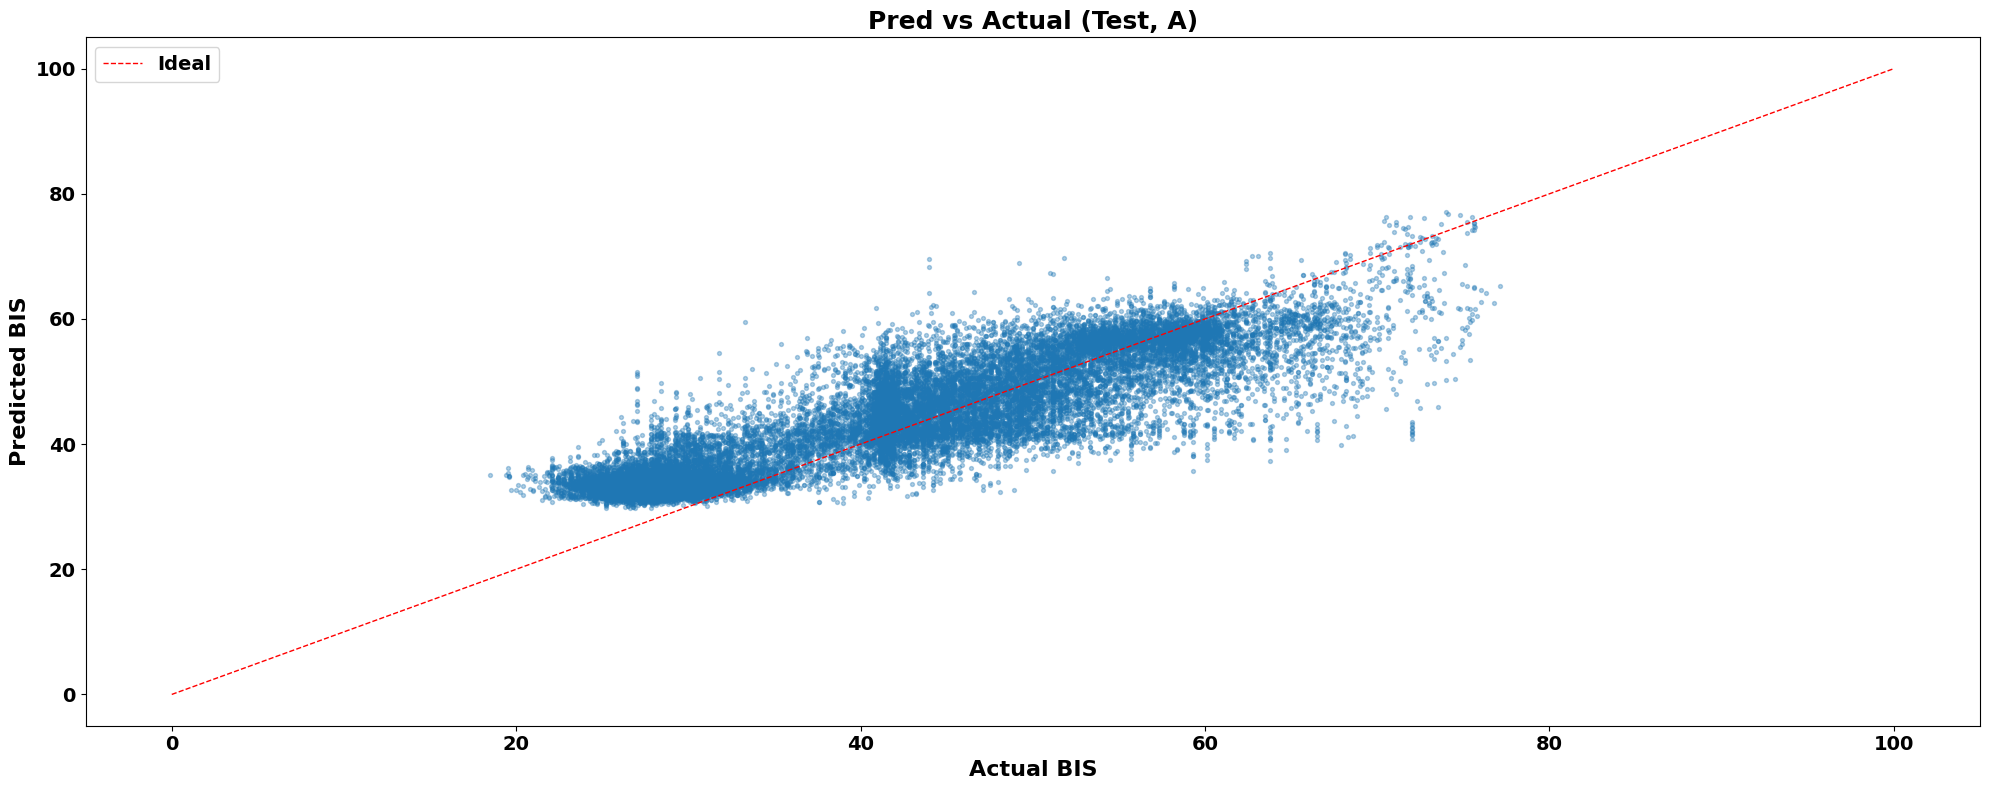

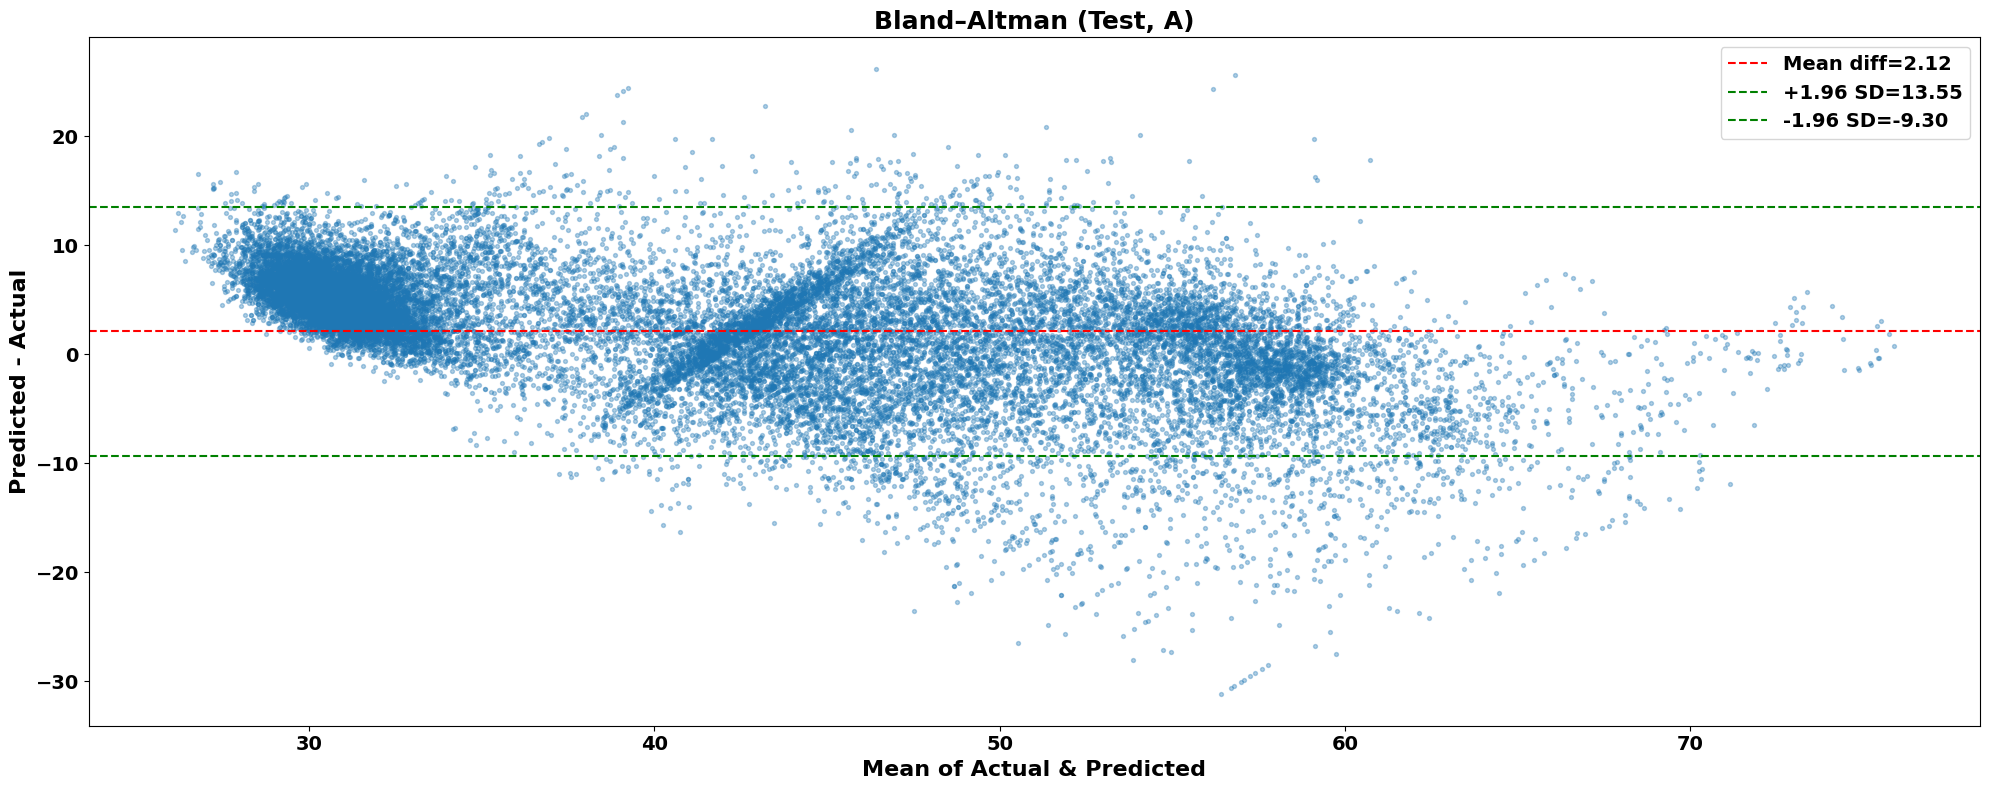

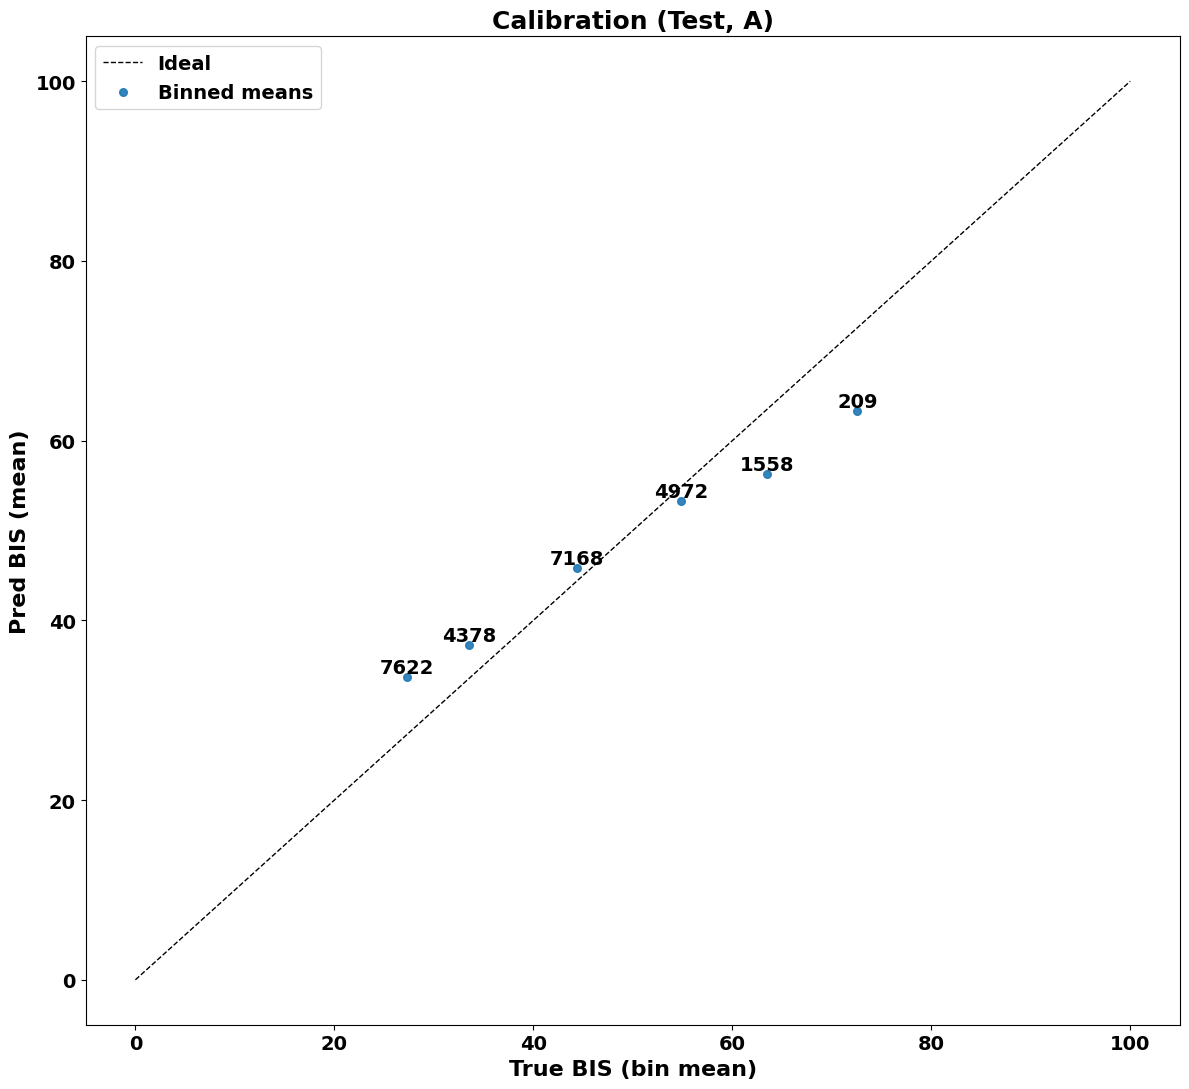

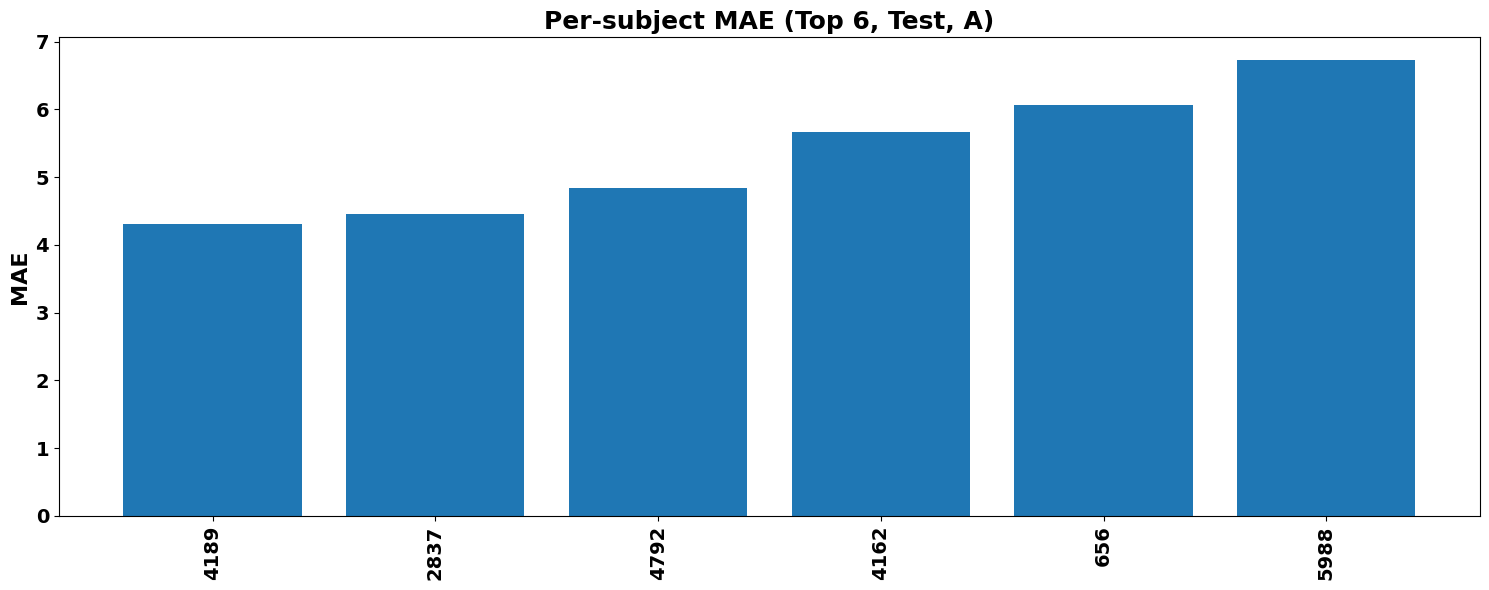

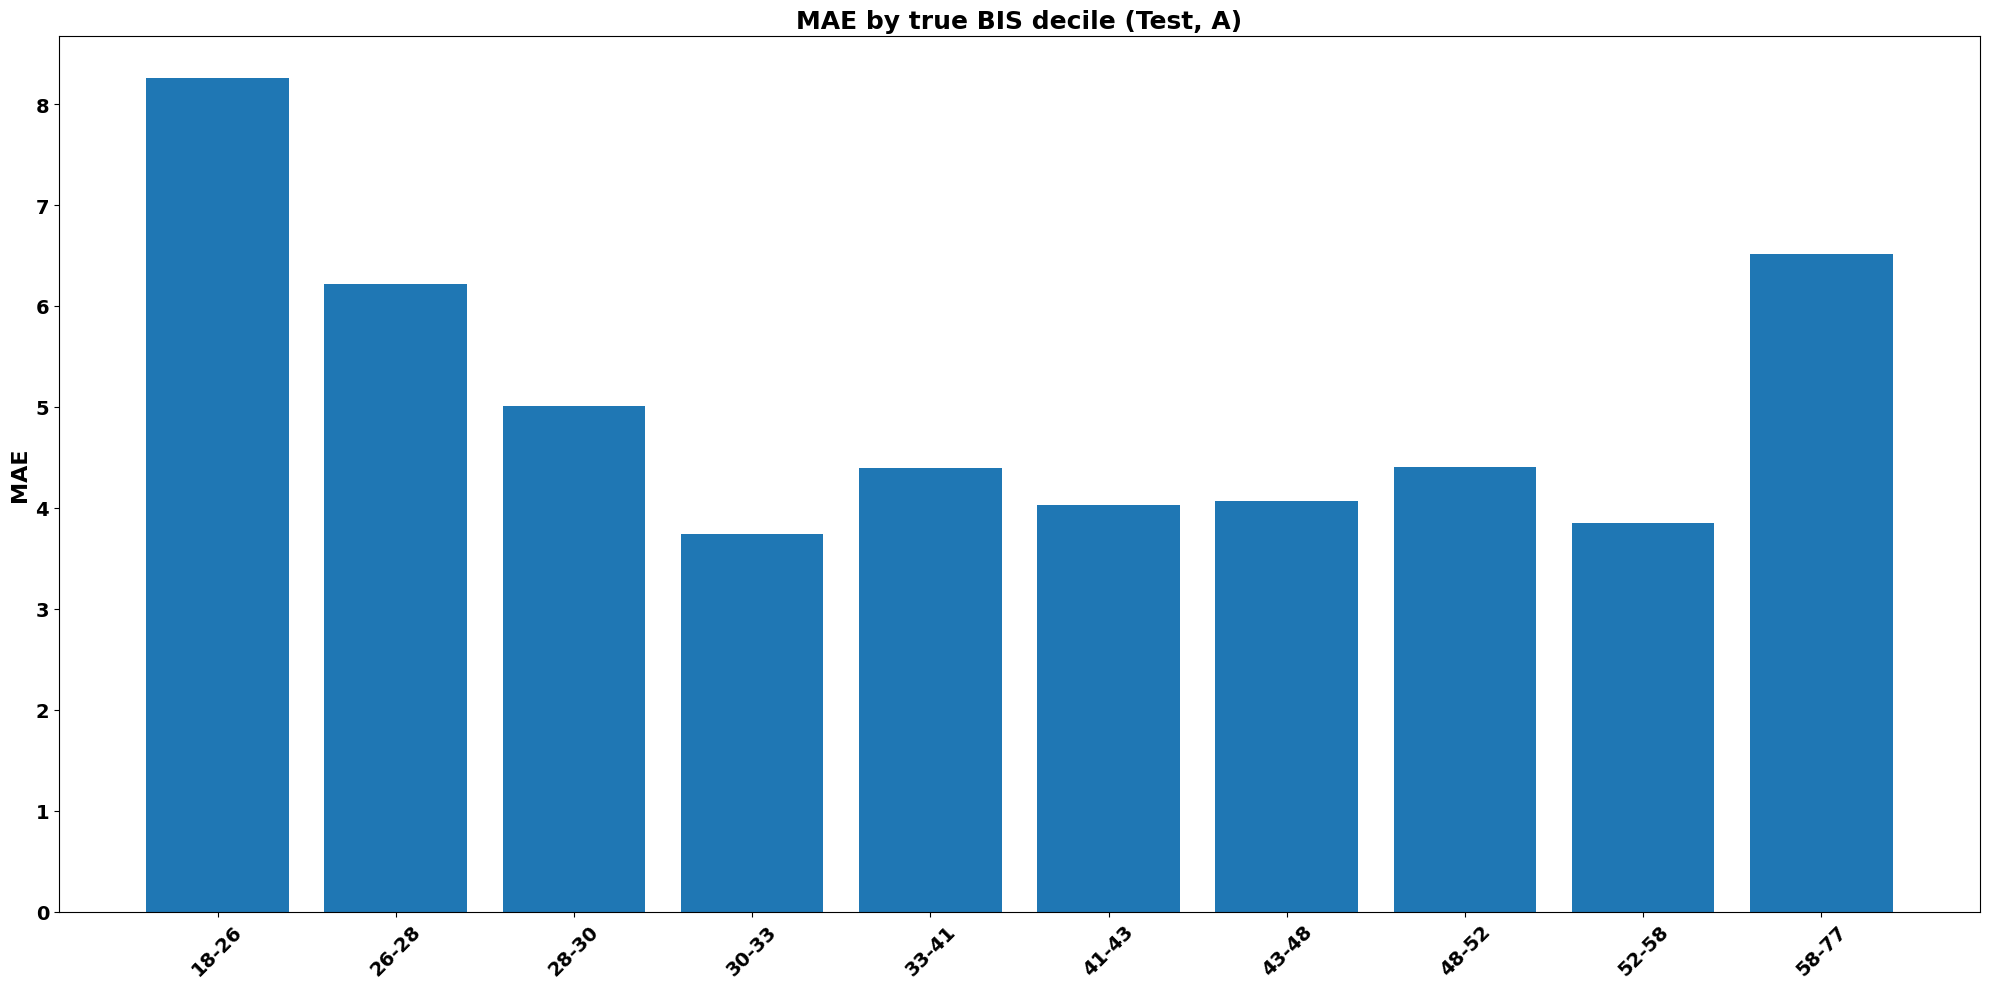

Saved all figures to: project\figures


In [14]:
# %% [markdown]
# ## 7) Plots

# %%
from sklearn.metrics import mean_absolute_error  # ensure available

def style_ax(ax, title=None, xlabel=None, ylabel=None, show_legend=False):
    if title is not None:
        ax.set_title(title, fontsize=18, fontweight='bold')
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=16, fontweight='bold')
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
    # ticks
    ax.tick_params(axis='both', labelsize=14)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontweight('bold')
    # legend
    if show_legend:
        leg = ax.legend(fontsize=14)
        for txt in leg.get_texts():
            txt.set_fontweight('bold')
    # no grid
    ax.grid(False)

# 1) Pred vs Actual
fig, ax = plt.subplots(figsize=(20, 8))
ax.scatter(y_true, y_pred, s=8, alpha=0.35)
ax.plot([0, 100], [0, 100], 'r--', lw=1, label='Ideal')
style_ax(ax,
         title=f"Pred vs Actual (Test, {COHORT})",
         xlabel="Actual BIS",
         ylabel="Predicted BIS",
         show_legend=True)
fig.tight_layout()
fig.savefig(DIR_FIGS / f"scatter_{COHORT}_test.png", dpi=200)
plt.show()

# 2) Bland–Altman
diff = y_pred - y_true
mean_vals = (y_pred + y_true) / 2
md = np.mean(diff); sd = np.std(diff, ddof=1)
loa_u, loa_l = md + 1.96 * sd, md - 1.96 * sd

fig, ax = plt.subplots(figsize=(20, 8))
ax.scatter(mean_vals, diff, s=8, alpha=0.35)
ax.axhline(md, color='r', ls='--', label=f"Mean diff={md:.2f}")
ax.axhline(loa_u, color='g', ls='--', label=f"+1.96 SD={loa_u:.2f}")
ax.axhline(loa_l, color='g', ls='--', label=f"-1.96 SD={loa_l:.2f}")
style_ax(ax,
         title=f"Bland–Altman (Test, {COHORT})",
         xlabel="Mean of Actual & Predicted",
         ylabel="Predicted - Actual",
         show_legend=True)
fig.tight_layout()
fig.savefig(DIR_FIGS / f"bland_altman_{COHORT}_test.png", dpi=200)
plt.show()

# 3) Calibration (binned mean pred vs true, bins on true)
bins = np.linspace(0, 100, 11)
bin_ids = np.digitize(y_true, bins) - 1
cal = []
for b in range(len(bins) - 1):
    m = (bin_ids == b)
    if m.sum() >= 10:
        cal.append((np.mean(y_true[m]), np.mean(y_pred[m]), m.sum()))
cal = np.array(cal) if len(cal) > 0 else np.empty((0, 3))

fig, ax = plt.subplots(figsize=(12, 11))
ax.plot([0, 100], [0, 100], 'k--', lw=1, label='Ideal')
if len(cal) > 0:
    ax.scatter(cal[:, 0], cal[:, 1], s=30, alpha=0.9, label='Binned means')
    for xt, yp, n in cal:
        ax.text(xt, yp, f"{int(n)}", fontsize=14, fontweight='bold',
                ha='center', va='bottom')
style_ax(ax,
         title=f"Calibration (Test, {COHORT})",
         xlabel="True BIS (bin mean)",
         ylabel="Pred BIS (mean)",
         show_legend=True)
fig.tight_layout()
fig.savefig(DIR_FIGS / f"calibration_{COHORT}_test.png", dpi=200)
plt.show()

# 4) Per-subject MAE (bar chart of top N; or histogram if many)
Nbar = min(30, len(df_per))
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(np.arange(Nbar), df_per["MAE"].values[:Nbar])
ax.set_xticks(np.arange(Nbar))
ax.set_xticklabels(df_per["caseid"].values[:Nbar], rotation=90)
style_ax(ax,
         title=f"Per-subject MAE (Top {Nbar}, Test, {COHORT})",
         xlabel=None,
         ylabel="MAE",
         show_legend=False)
fig.tight_layout()
fig.savefig(DIR_FIGS / f"per_subject_mae_{COHORT}_test.png", dpi=200)
plt.show()

# 5) Error by BIS decile (MAE per true-BIS bin)
deciles = np.percentile(y_true, np.arange(0, 110, 10))
dec_id = np.digitize(y_true, deciles) - 1
mae_by_bin = []
for b in range(len(deciles) - 1):
    m = (dec_id == b)
    if m.sum() >= 20:
        mae_by_bin.append((b, mean_absolute_error(y_true[m], y_pred[m]), m.sum()))
df_bin = pd.DataFrame(mae_by_bin, columns=["bin", "MAE", "count"])

fig, ax = plt.subplots(figsize=(20, 10))
ax.bar(df_bin["bin"], df_bin["MAE"])
ax.set_xticks(df_bin["bin"])
ax.set_xticklabels([f"{int(deciles[i])}-{int(deciles[i+1])}" for i in df_bin["bin"]], rotation=45)
style_ax(ax,
         title=f"MAE by true BIS decile (Test, {COHORT})",
         xlabel=None,
         ylabel="MAE",
         show_legend=False)
fig.tight_layout()
fig.savefig(DIR_FIGS / f"error_vs_truebin_{COHORT}_test.png", dpi=200)
plt.show()

print("Saved all figures to:", DIR_FIGS)


In [11]:
# %% [markdown]
# ## 7B) Per-subject plots (Pred vs Actual)

# %%
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# --- build a dataframe in-memory from current arrays (so we don't depend on parquet/csv reading) ---
df_sub = pd.DataFrame({
    "caseid": caseid_test.astype(int),
    "global_idx": gidx_test.astype(int),     # use as time order within subject
    "y_true": y_true.astype(float),
    "y_pred": y_pred.astype(float),          # clipped for reporting
})

# --- where to save ---
SUBJ_DIR = DIR_FIGS / f"subjects_{COHORT}"
SUBJ_DIR.mkdir(parents=True, exist_ok=True)
print("Saving subject plots to:", SUBJ_DIR)

# --- helper: consistent styling ---
def style_ax(ax, title=None, xlabel=None, ylabel=None, show_legend=False):
    if title is not None:
        ax.set_title(title, fontsize=18, fontweight='bold')
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=16, fontweight='bold')
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=14)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontweight('bold')
    if show_legend:
        leg = ax.legend(fontsize=14)
        for txt in leg.get_texts():
            txt.set_fontweight('bold')
    ax.grid(False)

# --- pick which subjects to plot ---
# Option A: save ALL subjects in test
SAVE_ALL = False

# Option B: only top/worst N by MAE
N_TOP = 10     # lowest MAE
N_WORST = 10   # highest MAE

# compute per-subject MAE
per_mae = (
    df_sub.groupby("caseid")
          .apply(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]))
          .rename("MAE")
          .reset_index()
)

if SAVE_ALL:
    caseids_to_plot = per_mae["caseid"].tolist()
else:
    top_ids   = per_mae.sort_values("MAE", ascending=True)["caseid"].head(N_TOP).tolist()
    worst_ids = per_mae.sort_values("MAE", ascending=False)["caseid"].head(N_WORST).tolist()
    # combine while preserving order and uniqueness
    caseids_to_plot = []
    for cid in top_ids + worst_ids:
        if cid not in caseids_to_plot:
            caseids_to_plot.append(cid)

print(f"Subjects to plot: {len(caseids_to_plot)} (SAVE_ALL={SAVE_ALL})")

# --- plotting loop ---
for cid in caseids_to_plot:
    d = df_sub[df_sub["caseid"] == cid].copy()
    # chronological order by global_idx (approx window time)
    d.sort_values("global_idx", inplace=True)
    t = np.arange(len(d))  # pseudo-time index (window order)
    mae_c = mean_absolute_error(d["y_true"], d["y_pred"])

    # 1) Time-series overlay
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, d["y_true"].values, lw=1.5, label="Actual BIS")
    ax.plot(t, d["y_pred"].values, lw=1.5, label="Predicted BIS")
    style_ax(
        ax,
        title=f"Subject {cid} — Time series (MAE={mae_c:.2f}, {COHORT})",
        xlabel="Window index (chronological)",
        ylabel="BIS",
        show_legend=True
    )
    fig.tight_layout()
    fig.savefig(SUBJ_DIR / f"subject_{cid}_timeseries_{COHORT}.png", dpi=200)
    plt.close(fig)

    # 2) Scatter (Pred vs Actual)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(d["y_true"].values, d["y_pred"].values, s=10, alpha=0.45)
    ax.plot([0, 100], [0, 100], 'r--', lw=1, label="Ideal")
    style_ax(
        ax,
        title=f"Subject {cid} — Scatter (MAE={mae_c:.2f}, {COHORT})",
        xlabel="Actual BIS",
        ylabel="Predicted BIS",
        show_legend=True
    )
    fig.tight_layout()
    fig.savefig(SUBJ_DIR / f"subject_{cid}_scatter_{COHORT}.png", dpi=200)
    plt.close(fig)

print("Done. Example saved files:")
for i, p in enumerate(sorted(SUBJ_DIR.glob("*.png"))[:6], 1):
    print(f"  {i:>2}. {p.name}")


Saving subject plots to: project\figures\subjects_A
Subjects to plot: 6 (SAVE_ALL=False)


C:\Users\user\AppData\Local\Temp\ipykernel_2068\1730382273.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sub.groupby("caseid")


Done. Example saved files:
   1. subject_2837_scatter_A.png
   2. subject_2837_timeseries_A.png
   3. subject_4162_scatter_A.png
   4. subject_4162_timeseries_A.png
   5. subject_4189_scatter_A.png
   6. subject_4189_timeseries_A.png


# (Optional) Dataset stats snapshot

In [12]:
# %% [markdown]
# ## 8) Dataset stats (optional but useful)





# %%
stats = {
    "cohort": COHORT,
    "n_segments_total": int(n_x),
    "n_subjects_total": int(n_c),
    "n_train_segments": int(n_train_segments),
    "n_val_segments": int(n_val_segments),
    "n_test_segments": int(n_test_segments),
    "n_train_subjects": int(len(train_caseids)),
    "n_val_subjects": int(len(val_caseids)),
    "n_test_subjects": int(len(test_caseids)),
}
with open(DIR_STATS / f"stats_{COHORT}.json", "w") as f:
    json.dump(stats, f, indent=2)
print("Saved stats →", DIR_STATS / f"stats_{COHORT}.json")


Saved stats → project\stats\stats_A.json
